In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohankayan/years-of-experience-and-salary-dataset/Salary_Data.csv


# 📊 Regression Metrics — Linear Regression

## 1. What are Regression Metrics?

Regression metrics are used to **evaluate how well a regression model performs**.

A regression model predicts a continuous numerical value such as:

- Salary
- House Price
- Temperature
- Sales
- Revenue

After training the model, we compare:

$$
Actual\ Value \quad vs \quad Predicted\ Value
$$

The difference between them is called the **error** or **residual**.

$$
Error = y - \hat{y}
$$

Where:

- $y$ = Actual value
- $\hat{y}$ = Predicted value

A good regression model should have **small prediction errors**.

---

## 2. Dataset Used

For this implementation, we use a **Salary vs Years of Experience** dataset.

### Features

**Independent Variable (X):**

$$
X = Years\ of\ Experience
$$

**Target Variable (y):**

$$
y = Salary
$$

Our goal is:

> **Predict a person's salary based on their years of experience using Linear Regression.**

---

## 3. Linear Regression

Linear Regression tries to find the **best-fitting straight line** between the input and target.

The equation is:

$$
\hat{y} = b_0 + b_1x
$$

Where:

- $\hat{y}$ = Predicted value
- $b_0$ = Intercept
- $b_1$ = Coefficient / Slope
- $x$ = Input feature

The model learns the values of $b_0$ and $b_1$ from the training data.

---

## 4. Why Do We Need Regression Metrics?

Suppose our model predicts:

| Actual Salary | Predicted Salary |
|---:|---:|
| 50,000 | 48,000 |
| 60,000 | 63,000 |
| 70,000 | 68,000 |

The predictions are not exactly equal to the actual values.

Therefore, we need metrics to answer:

> **How good is our regression model?**

The main regression metrics are:

1. MAE — Mean Absolute Error
2. MSE — Mean Squared Error
3. RMSE — Root Mean Squared Error
4. R² Score — R-Squared
5. Adjusted R² Score

---

# 5. MAE — Mean Absolute Error

MAE measures the **average absolute difference** between actual and predicted values.

### Formula

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

### Intuition

If:

$$
MAE = 5000
$$

then the model's predictions are off by approximately **5,000 units on average**.

### Important Points

- Easy to understand
- Same unit as the target variable
- Every error gets equal importance
- Less sensitive to outliers than MSE

### Lower MAE → Better Model

---

# 6. MSE — Mean Squared Error

MSE calculates the average of the **squared errors**.

### Formula

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

The errors are squared, so **large errors receive much higher penalties**.

For example:

$$
Error = 2
$$

$$
Error^2 = 4
$$

But:

$$
Error = 10
$$

$$
Error^2 = 100
$$

Therefore, MSE is more sensitive to large errors and outliers.

### Lower MSE → Better Model

---

# 7. RMSE — Root Mean Squared Error

RMSE is the square root of MSE.

### Formula

$$
RMSE = \sqrt{MSE}
$$

RMSE brings the error back to the **same unit as the target variable**.

For example, if salary is measured in rupees:

$$
RMSE = ₹5000
$$

This means the model's typical prediction error is around ₹5,000.

### Important Points

- Same unit as target
- Penalizes large errors
- Easier to interpret than MSE

### Lower RMSE → Better Model

---

# 8. R² Score — R-Squared

R² measures how much of the **variation in the target variable is explained by the regression model**.

### Formula

$$
R^2 =
1-\frac{SS_{res}}{SS_{tot}}
$$

Where:

- $SS_{res}$ = Sum of Squared Residuals
- $SS_{tot}$ = Total Sum of Squares

### Example

If:

$$
R^2 = 0.80
$$

the model explains approximately **80% of the variation** in the target variable.

### Interpretation

$$
R^2 = 1
$$

Perfect prediction.

$$
R^2 = 0
$$

Model does not explain the variation better than the mean baseline.

$$
R^2 < 0
$$

The model can perform worse than the mean baseline.

### Higher R² → Generally Better

---

# 9. Adjusted R² Score

Adjusted R² is a modified version of R² that takes the **number of features in the model** into account.

### Formula

$$
Adjusted\ R^2 =
1-(1-R^2)\frac{n-1}{n-k-1}
$$

Where:

- $R^2$ = R² Score
- $n$ = Number of observations
- $k$ = Number of independent variables

### Why do we need Adjusted R²?

Adding more features can increase R² even when those features are not actually useful.

Adjusted R² **penalizes unnecessary features**.

Therefore, it is especially useful when working with **Multiple Linear Regression**.

---

# 10. R² vs Adjusted R²

| Metric | R² | Adjusted R² |
|---|---|---|
| Measures explained variation | ✅ | ✅ |
| Considers number of features | ❌ | ✅ |
| Can increase by adding features | ✅ | Not necessarily |
| Penalizes unnecessary features | ❌ | ✅ |
| Useful for multiple regression | ✅ | ⭐ Very useful |

---

# 11. Comparing Regression Metrics

| Metric | What it measures | Better Value |
|---|---|---|
| MAE | Average absolute error | Lower |
| MSE | Average squared error | Lower |
| RMSE | Typical error in original unit | Lower |
| R² | Variation explained by model | Higher |
| Adjusted R² | Variation explained with feature penalty | Higher |

---

# 12. Complete Machine Learning Workflow

```text
Dataset
   ↓
Data Understanding
   ↓
EDA
   ↓
Select X and y
   ↓
Train-Test Split
   ↓
Train Linear Regression Model
   ↓
Make Predictions
   ↓
Compare Actual vs Predicted
   ↓
Calculate Regression Metrics
   ↓
MAE
MSE
RMSE
R²
Adjusted R²
   ↓
Evaluate Model

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohankayan/years-of-experience-and-salary-dataset/Salary_Data.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/rohankayan/years-of-experience-and-salary-dataset/Salary_Data.csv')

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.shape

(30, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [7]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [8]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [9]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

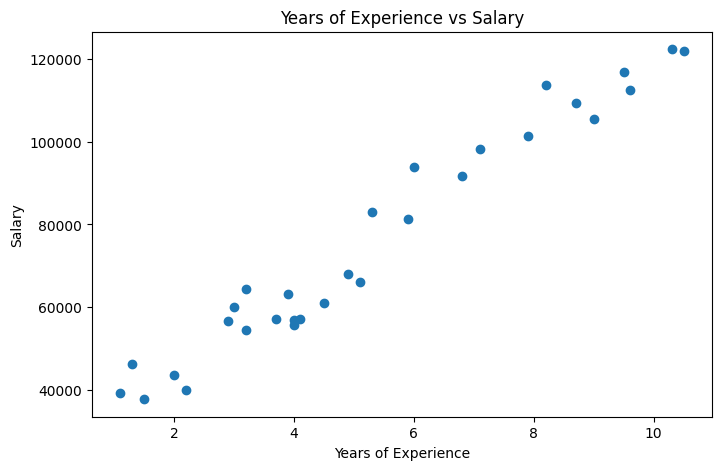

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(df['YearsExperience'], df['Salary'])

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')

plt.show()

In [16]:
X = df[['YearsExperience']]
y = df['Salary']

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 1)
y shape: (30,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 24
Testing samples : 6


In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

LinearRegression()

In [24]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 9423.815323030976
Intercept: 25321.583011776813


In [25]:
print(
    f"Salary = {model.intercept_:.2f} + "
    f"({model.coef_[0]:.2f} × YearsExperience)"
)

Salary = 25321.58 + (9423.82 × YearsExperience)


In [26]:
y_pred = model.predict(X_test)


In [27]:
comparison = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

comparison.head(10)

,Actual Salary,Predicted Salary
0,112635.0,115790.210113
1,67938.0,71498.278095
2,113812.0,102596.868661
3,83088.0,75267.804224
4,64445.0,55477.792045
5,57189.0,60189.699707


In [28]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 6286.453830757749


In [29]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 49830096.85590839


In [30]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 7059.04362190151


In [31]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9024461774180497


In [32]:
n = X_test.shape[0]
k = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.878057721772562
